## Step 1: Exploratory Data Analysis

### Dataset loaded: `../data/retail_customer_data.csv` (1000 rows, 31 columns)

### Data Preview

,age,gender,annual_income,education,marital_status,city,state,country,postal_code,signup_date,purchase_frequency,avg_purchase_value,total_spent,days_since_last_purchase,favorite_payment_method,electronics_score,clothing_score,home_decor_score,beauty_score,sports_score,books_score,food_score,website_visits_per_month,avg_session_duration,mobile_app_usage,desktop_usage,items_viewed_per_visit,cart_abandonment_rate,email_engagement_rate,support_tickets,satisfaction_score
0,58,Male,76754,High School,Divorced,Curtisfurt,CT,US,47553,2023-11-26,7,30.46,213.20,29,Debit Card,53,81,52,84,74,49,48,3,11.70,6,96,7,54,0,1,7.0
1,19,Non-binary,36083,Associate Degree,Widowed,New Jessica,GA,US,61090,2024-01-15,7,36.78,257.47,58,Google Pay,17,27,44,38,34,26,30,2,8.08,95,0,12,59,16,1,5.6
2,42,Male,45852,Bachelor Degree,Divorced,Hurstfurt,MN,US,29247,2021-11-21,13,33.38,433.95,34,Credit Card,75,80,53,70,51,81,64,2,9.21,91,18,7,40,65,0,6.9
3,30,Non-binary,34021,High School,Single,Teresaburgh,NY,US,14448,2021-07-26,5,35.45,177.27,30,PayPal,19,11,29,22,34,45,28,5,4.24,17,79,13,51,23,1,6.4
4,62,Non-binary,90889,High School,Married,East Donna,OH,US,22144,2022-04-13,9,45.37,408.32,94,Debit Card,39,34,27,50,45,24,30,1,8.77,75,12,15,62,42,0,6.9


### Column Data Types

...

### Missing Values Summary

Series([], dtype: int64)

### Skewness of Numerical Features

,Skew,Normal-like (No Transform Needed),Skewed (Consider Transforming)
annual_income,1.563020,False,True
total_spent,1.517011,False,True
support_tickets,1.193122,False,True
avg_purchase_value,0.970199,True,False
website_visits_per_month,0.417386,True,False
purchase_frequency,0.341751,True,False
items_viewed_per_visit,0.292577,True,False
email_engagement_rate,0.177611,True,False
satisfaction_score,-0.154793,True,False
avg_session_duration,0.142264,True,False


### Distribution of Numerical Features

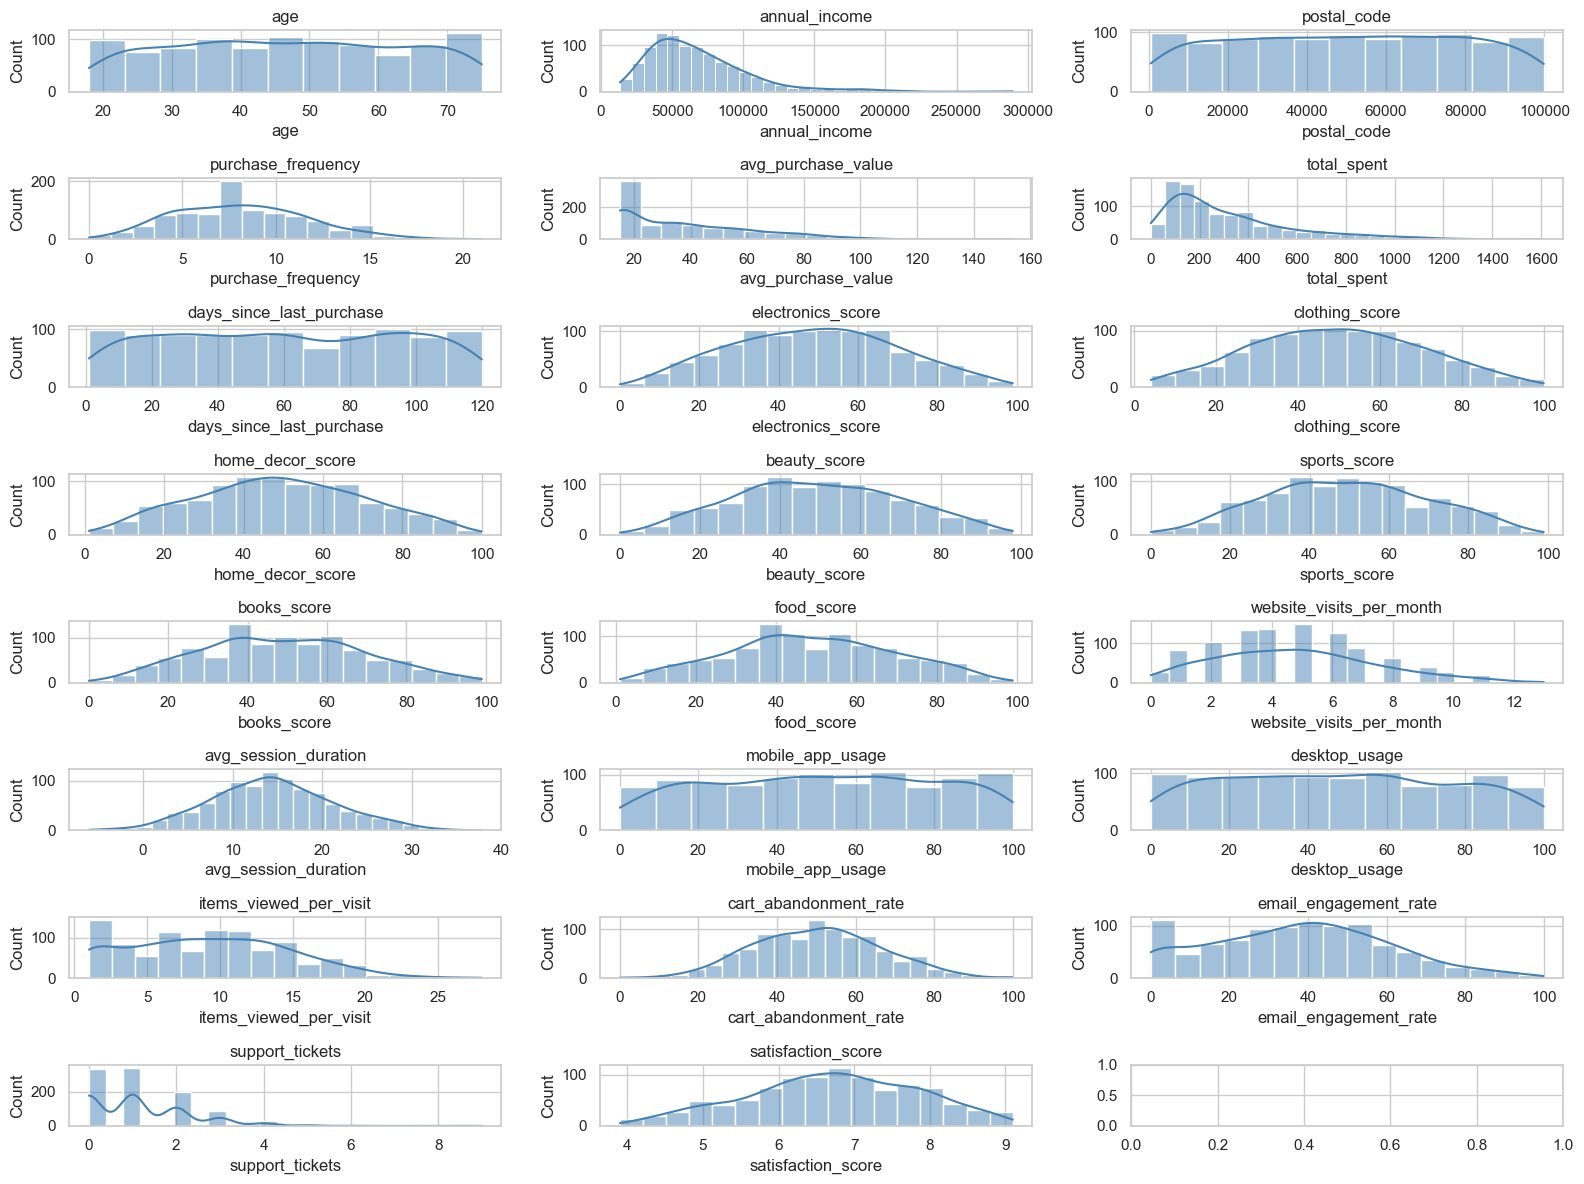

### Frequency of Categorical Features

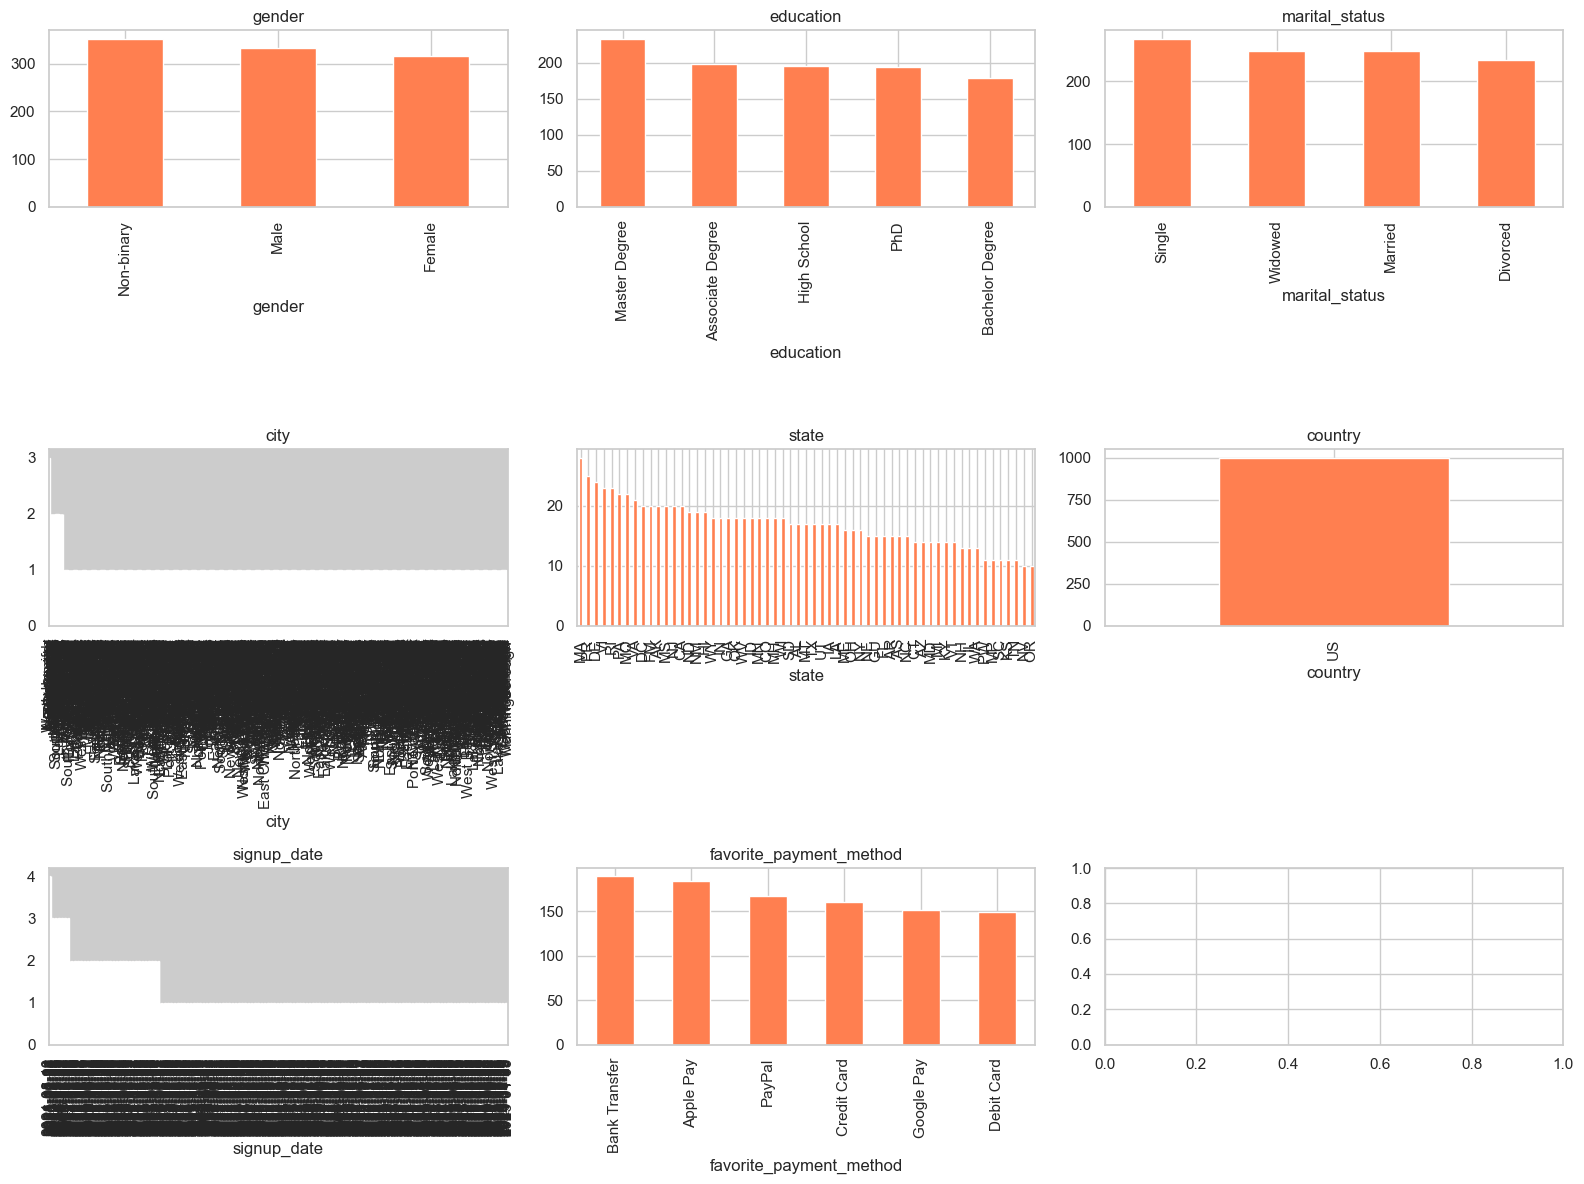

### Correlation Matrix of Numerical Features

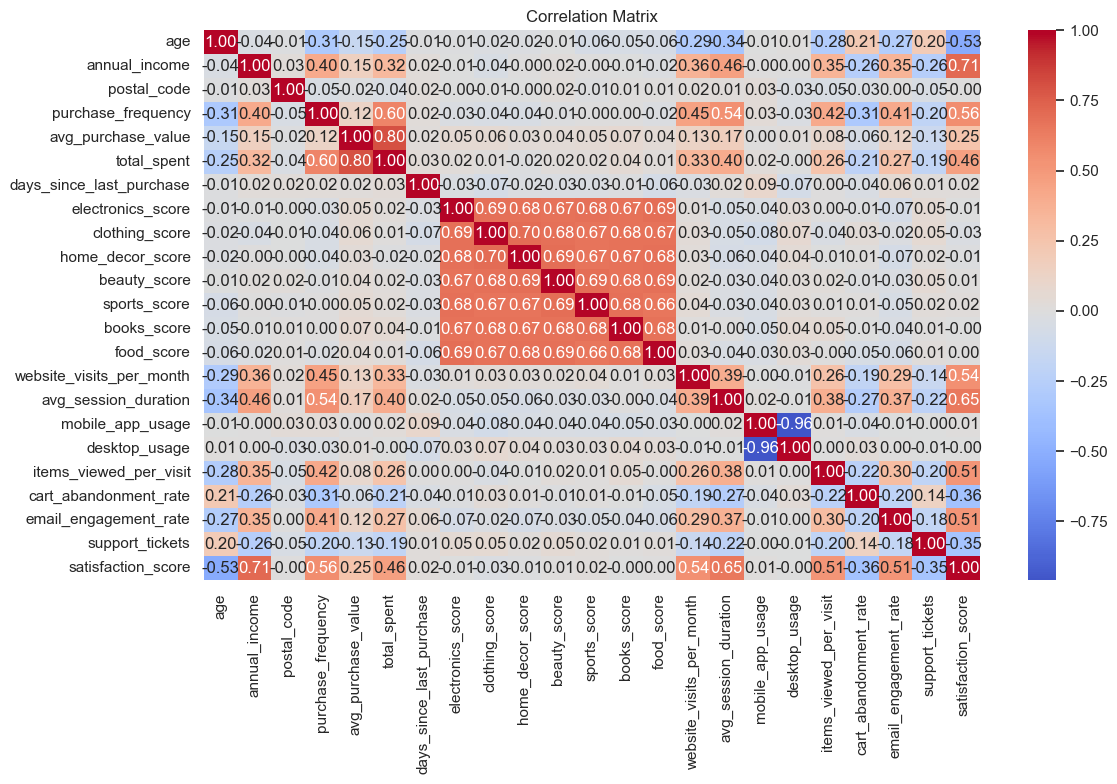

📁 EDA reports saved to ../docs/
✅ Step 1: EDA completed successfully!


In [1]:
# Step 1: Exploratory Data Analysis (EDA)

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set display options
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# --- Load Data ---
display(Markdown("## Step 1: Exploratory Data Analysis"))

file_path = "../data/retail_customer_data.csv"
df = pd.read_csv(file_path)
df = df.drop(columns=['customer_id'], errors='ignore') 
display(Markdown(f"### Dataset loaded: `{file_path}` ({df.shape[0]} rows, {df.shape[1]} columns)"))

# --- Basic Info ---
display(Markdown("### Data Preview"))
display(df.head())
display(Markdown("### Column Data Types"))
display(df.dtypes)

# --- Missing Values ---
display(Markdown("### Missing Values Summary"))
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
display(missing_summary)

# --- Univariate Analysis ---
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# --- Skewness Summary ---
display(Markdown("### Skewness of Numerical Features"))
skew_data = pd.DataFrame({
    "Skew": df[numeric_cols].skew(),
    "Normal-like (No Transform Needed)": df[numeric_cols].skew().abs() < 1,
    "Skewed (Consider Transforming)": df[numeric_cols].skew().abs() >= 1
})
display(skew_data.sort_values("Skew", key=np.abs, ascending=False))

# --- Histograms for Numeric Columns ---
display(Markdown("### Distribution of Numerical Features"))
fig, axs = plt.subplots(nrows=(len(numeric_cols) + 2) // 3, ncols=3, figsize=(16, 12))
axs = axs.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axs[i], color='steelblue')
    axs[i].set_title(col)
plt.tight_layout()
plt.show()

# --- Bar plots for Categorical Columns ---
display(Markdown("### Frequency of Categorical Features"))
fig, axs = plt.subplots(nrows=(len(categorical_cols) + 2) // 3, ncols=3, figsize=(16, 12))
axs = axs.flatten()
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axs[i], color='coral')
    axs[i].set_title(col)
plt.tight_layout()
plt.show()

# --- Correlation Matrix ---
display(Markdown("### Correlation Matrix of Numerical Features"))
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# --- Save Summary Report ---
os.makedirs("../docs", exist_ok=True)
df.describe().to_csv("../docs/step1_numeric_summary.csv")
skew_data.to_csv("../docs/step1_skewness_report.csv")
missing_summary.to_csv("../docs/step1_missing_report.csv")

print("📁 EDA reports saved to ../docs/")
print("✅ Step 1: EDA completed successfully!")

In [4]:
# Step 2: Data Preprocessing for Unsupervised Learning

from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os

# --- Load Data ---
display(Markdown("## Step 2: Data Preprocessing"))
df = pd.read_csv("../data/retail_customer_data.csv")

# --- Separate columns ---
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

# --- Identify highly skewed numeric features ---
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewed_features = skewness[abs(skewness) > 1.0].index.tolist()
normal_features = list(set(numeric_cols) - set(skewed_features))

# --- Imputation ---
numeric_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# --- Transformation pipelines ---
numeric_pipeline = Pipeline([
    ("imputer", numeric_imputer),
    ("scaler", StandardScaler())
])

skewed_pipeline = Pipeline([
    ("imputer", numeric_imputer),
    ("power", PowerTransformer(method='yeo-johnson')),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", categorical_imputer),
    ("encoder", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# --- Combine transformers ---
preprocessor = ColumnTransformer(transformers=[
    ("normal_num", numeric_pipeline, normal_features),
    ("skewed_num", skewed_pipeline, skewed_features),
    ("cat", categorical_pipeline, categorical_cols)
])

# --- Apply transformations ---
processed_array = preprocessor.fit_transform(df)
processed_feature_names = (
    normal_features + skewed_features +
    list(preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_cols))
)

# --- Create final DataFrame ---
processed_df = pd.DataFrame(processed_array, columns=processed_feature_names)
processed_df.index = df.index

# --- Save cleaned data ---
os.makedirs("../data/processed", exist_ok=True)
processed_df.to_csv("../data/processed/retail_customer_cleaned.csv", index=False)

# --- Report ---
display(Markdown("### ✅ Preprocessing Complete"))
display(Markdown(f"Processed dataset shape: **{processed_df.shape}**"))
display(Markdown("Saved to: `../data/processed/retail_customer_cleaned.csv`"))
print("✅ Step 2: Data preprocessing completed successfully!")
print("📁 Processed data saved to ../data/processed/")

## Step 2: Data Preprocessing

### ✅ Preprocessing Complete

Processed dataset shape: **(1000, 2835)**

Saved to: `../data/processed/retail_customer_cleaned.csv`

✅ Step 2: Data preprocessing completed successfully!
📁 Processed data saved to ../data/processed/


## Step 3: Dimensionality Reduction

### Principal Component Analysis (PCA)

Retained 923 components explaining 95% variance.

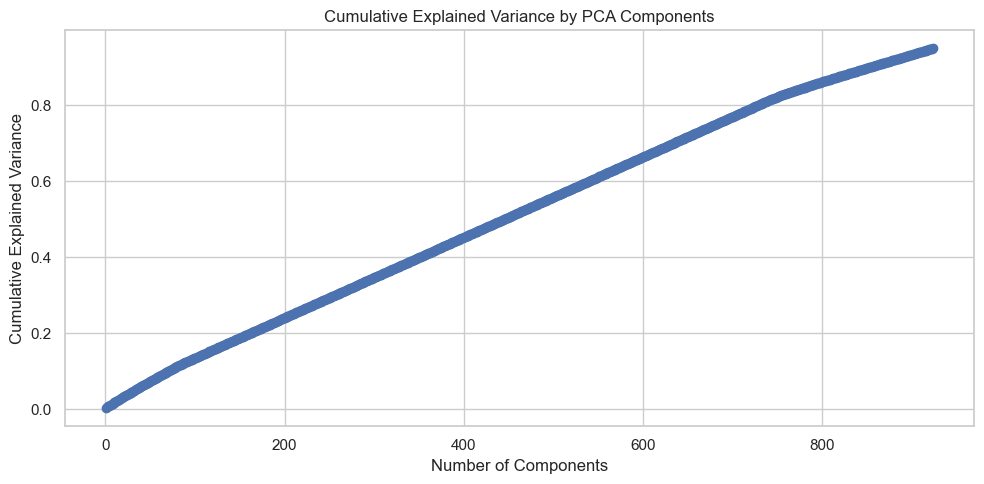

### t-SNE Visualization (2D)

### 2D PCA Visualization

### Visual Comparison: PCA vs t-SNE (2D)

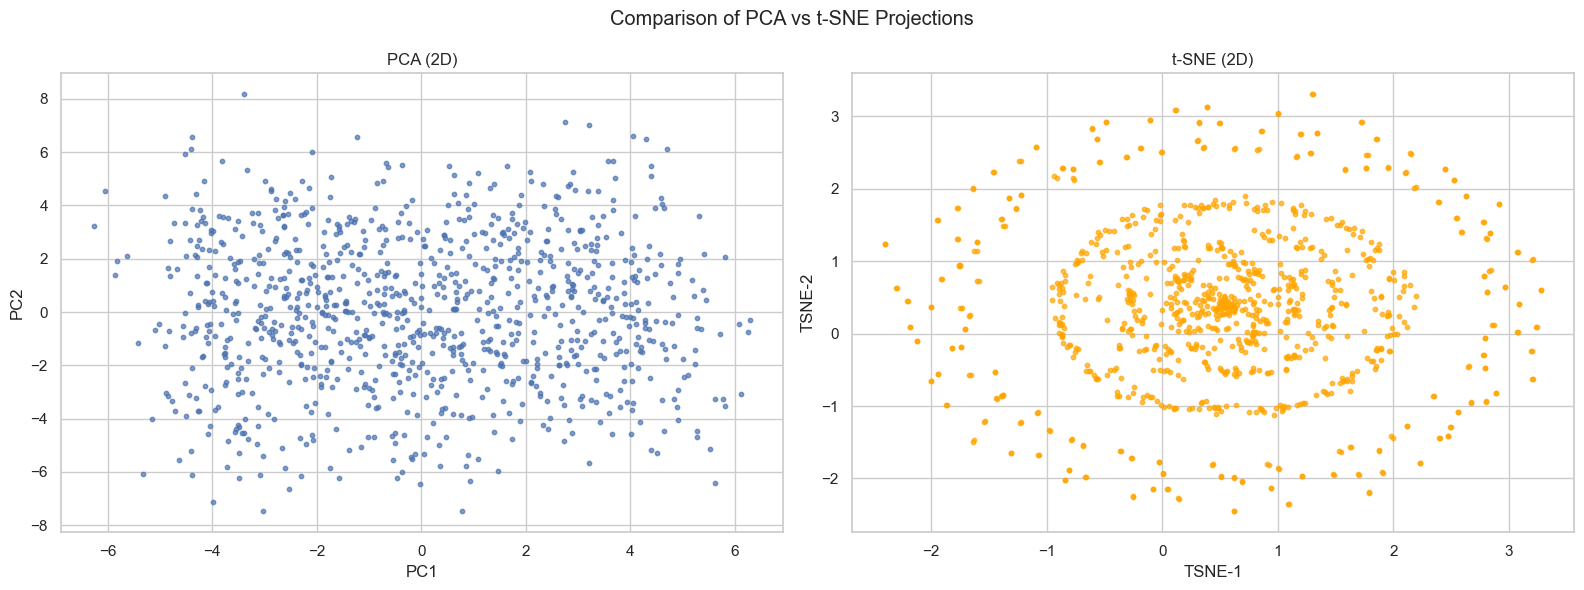


### 🧠 PCA vs t-SNE: Interpretation
- **PCA** captures global structure and linear relationships in the data.
- **t-SNE** focuses on preserving local distances, useful for visualizing clusters.
- PCA is deterministic and fast; t-SNE is stochastic and slower, but often reveals non-linear patterns.
- t-SNE should not be used for dimensionality reduction prior to clustering; it’s primarily for visualization.


✅ PCA-reduced dataset saved to ../data/processed/pca_reduced_data.csv
✅ Step 3: Dimensionality reduction completed successfully!


In [6]:
# Step 3: Dimensionality Reduction

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load preprocessed dataset
file_path = "../data/processed/retail_customer_cleaned.csv"
display(Markdown("## Step 3: Dimensionality Reduction"))
df = pd.read_csv(file_path)

# --- PCA ---
display(Markdown("### Principal Component Analysis (PCA)"))
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca = PCA(n_components=0.95)  # retain 95% variance
pca_components = pca.fit_transform(df_scaled)

display(Markdown(f"Retained {pca.n_components_} components explaining 95% variance."))

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- t-SNE ---
display(Markdown("### t-SNE Visualization (2D)"))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(df_scaled)

# --- 2D PCA for visual comparison ---
display(Markdown("### 2D PCA Visualization"))
pca_2d = PCA(n_components=2)
pca_2d_results = pca_2d.fit_transform(df_scaled)

# --- Side-by-side comparison ---
display(Markdown("### Visual Comparison: PCA vs t-SNE (2D)"))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.scatter(pca_2d_results[:, 0], pca_2d_results[:, 1], s=10, alpha=0.7)
ax1.set_title("PCA (2D)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

ax2.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.7, color='orange')
ax2.set_title("t-SNE (2D)")
ax2.set_xlabel("TSNE-1")
ax2.set_ylabel("TSNE-2")

plt.suptitle("Comparison of PCA vs t-SNE Projections")
plt.tight_layout()
plt.show()

# --- Commentary ---
display(Markdown("""
### 🧠 PCA vs t-SNE: Interpretation
- **PCA** captures global structure and linear relationships in the data.
- **t-SNE** focuses on preserving local distances, useful for visualizing clusters.
- PCA is deterministic and fast; t-SNE is stochastic and slower, but often reveals non-linear patterns.
- t-SNE should not be used for dimensionality reduction prior to clustering; it’s primarily for visualization.
"""))

# Save PCA output for clustering
pca_df = pd.DataFrame(pca_components, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
pca_df.to_csv("../data/processed/pca_reduced_data.csv", index=False)

print("✅ PCA-reduced dataset saved to ../data/processed/pca_reduced_data.csv")
print("✅ Step 3: Dimensionality reduction completed successfully!")